# Hoffmann & Spang ERA5 tropopause data: first look at one file

Source: Jülich Reanalysis Tropopause Data Repository (Hoffmann & Spang, 2022), v2, `era5low`.
https://datapub.fz-juelich.de/slcs/tropopause/ (CC BY 4.0, doi:10.26165/JUELICH-DATA/UBNGI2)

Goal: download one daily file, check its structure (variable names, units, grid, time steps),
and map tropopause height, with the 43,000 ft level marked for reference.

In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    from cartopy.util import add_cyclic_point
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False
print("cartopy available:", HAVE_CARTOPY)

URL = "https://datapub.fz-juelich.de/slcs/tropopause/data/v2/era5low/2025/era5low_2025_01_01.nc"
LOCAL = os.path.basename(URL)

CEIL_KM = 43000 * 0.3048 / 1000   # 13.106 km, for reference contours only

cartopy available: True


## 1. Download and open

In [2]:
if not os.path.exists(LOCAL):
    urllib.request.urlretrieve(URL, LOCAL)
print(f"{LOCAL}: {os.path.getsize(LOCAL) / 1e6:.1f} MB")

ds = xr.open_dataset(LOCAL)
ds

era5low_2025_01_01.nc: 18.9 MB


<xarray.Dataset> Size: 19MB
Dimensions:    (time: 4, lat: 181, lon: 361)
Coordinates:
  * time       (time) datetime64[ns] 32B 2025-01-01 ... 2025-01-01T18:00:00
  * lat        (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon        (lon) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0 180.0
Data variables: (12/18)
    clp_z      (time, lat, lon) float32 1MB ...
    clp_p      (time, lat, lon) float32 1MB ...
    clp_t      (time, lat, lon) float32 1MB ...
    clp_q      (time, lat, lon) float32 1MB ...
    dyn_z      (time, lat, lon) float32 1MB ...
    dyn_p      (time, lat, lon) float32 1MB ...
    ...         ...
    wmo_2nd_z  (time, lat, lon) float32 1MB ...
    wmo_2nd_p  (time, lat, lon) float32 1MB ...
    wmo_2nd_t  (time, lat, lon) float32 1MB ...
    wmo_2nd_q  (time, lat, lon) float32 1MB ...
    ps         (time, lat, lon) float32 1MB ...
    zs         (time, lat, lon) float32 1MB ...

## 2. Structure: dimensions, coordinates, global attributes

In [3]:
print("Dimensions:", dict(ds.sizes))

print("\nCoordinates:")
for c in ds.coords:
    v = ds[c]
    print(f"  {c:12s} dims={v.dims} dtype={v.dtype} "
          f"range={v.values.min()} .. {v.values.max()} units={v.attrs.get('units', '')!r}")

print("\nGlobal attributes:")
for k, v in ds.attrs.items():
    print(f"  {k}: {v}")

Dimensions: {'time': 4, 'lat': 181, 'lon': 361}

Coordinates:
  time         dims=('time',) dtype=datetime64[ns] range=2025-01-01T00:00:00.000000000 .. 2025-01-01T18:00:00.000000000 units=''
  lat          dims=('lat',) dtype=float64 range=-90.0 .. 90.0 units='degrees_north'
  lon          dims=('lon',) dtype=float64 range=-180.0 .. 180.0 units='degrees_east'

Global attributes:


## 3. Data variables

Units and ranges matter here: the height variables could be in km, m, or geopotential (m² s⁻²),
and temperature should be in K. The valid fraction shows how often each definition finds a
tropopause (expect `wmo_2nd` to be sparse).

In [4]:
rows = []
for name, v in ds.data_vars.items():
    a = v.values
    if np.issubdtype(a.dtype, np.number):
        fin = np.isfinite(a)
        vmin = np.nanmin(a) if fin.any() else np.nan
        vmax = np.nanmax(a) if fin.any() else np.nan
        frac = fin.mean()
    else:
        vmin = vmax = frac = np.nan
    rows.append(dict(var=name, dims=" x ".join(v.dims), units=v.attrs.get("units", ""),
                     long_name=v.attrs.get("long_name", ""),
                     min=vmin, max=vmax, frac_valid=frac))

pd.set_option("display.max_colwidth", 80)
pd.DataFrame(rows).set_index("var")

,dims,units,long_name,min,max,frac_valid
var,,,,,,
clp_z,time x lat x lon,km,cold point height,6.333595,21.065113,0.831480
clp_p,time x lat x lon,hPa,cold point pressure,47.644890,411.956696,0.831480
clp_t,time x lat x lon,K,cold point temperature,184.054092,231.945770,0.831480
clp_q,time x lat x lon,ppv,cold point water vapor,0.000001,0.000153,0.831480
dyn_z,time x lat x lon,km,dynamical tropopause height,4.607516,17.889887,0.999820
dyn_p,time x lat x lon,hPa,dynamical tropopause pressure,79.683388,525.198059,0.999820
dyn_t,time x lat x lon,K,dynamical tropopause temperature,185.041229,255.911438,0.999820
dyn_q,time x lat x lon,ppv,dynamical tropopause water vapor,0.000001,0.000408,0.999820
wmo_1st_z,time x lat x lon,km,WMO 1st tropopause height,4.618207,20.008852,0.999973


## 4. Grid and time checks

In [5]:
def find(names):
    for n in names:
        if n in ds.variables or n in ds.dims:
            return n
    raise KeyError(f"none of {names} found; have {list(ds.variables)}")

LAT = find(["lat", "latitude"])
LON = find(["lon", "longitude"])
TIME = next((d for d in ds[list(ds.data_vars)[0]].dims if d not in (LAT, LON)), None)

lat, lon = ds[LAT].values, ds[LON].values
print(f"lat: {lat.size} points, {lat[0]} .. {lat[-1]}, spacing {np.unique(np.round(np.diff(lat), 4))}")
print(f"lon: {lon.size} points, {lon[0]} .. {lon[-1]}, spacing {np.unique(np.round(np.diff(lon), 4))}")
print(f"time dim: {TIME!r}", "" if TIME is None else f"-> {ds[TIME].values}")

lat: 181 points, -90.0 .. 90.0, spacing [1.]
lon: 361 points, -180.0 .. 180.0, spacing [1.]
time dim: 'time' -> ['2025-01-01T00:00:00.000000000' '2025-01-01T06:00:00.000000000'
 '2025-01-01T12:00:00.000000000' '2025-01-01T18:00:00.000000000']


## 5. Tropopause height variables

Hoffmann & Spang provide four definitions: `dyn` (3.5 PVU, 380 K in the tropics),
`wmo_1st`, `wmo_2nd` (WMO lapse-rate, first and second), and `clp` (cold point).
The cell below finds height variables by the `_z` suffix; check the list against the table above.

In [6]:
ZVARS = [v for v in ds.data_vars if v.endswith("_z")]
print("height variables:", ZVARS)


def to_km(da):
    u = da.attrs.get("units", "").strip().lower()
    if u == "km":
        return da
    if u in ("m", "gpm"):
        return da / 1000.0
    if u in ("m2 s-2", "m**2 s**-2", "m^2 s^-2"):
        return da / (9.80665 * 1000.0)
    raise ValueError(f"{da.name}: unrecognised height units {u!r}; set conversion by hand")


for v in ZVARS:
    z = to_km(ds[v])
    print(f"  {v:10s} units={ds[v].attrs.get('units', '')!r:10s} "
          f"km range {float(z.min()):.2f} .. {float(z.max()):.2f}")

height variables: ['clp_z', 'dyn_z', 'wmo_1st_z', 'wmo_2nd_z']


  clp_z      units='km'       km range 6.33 .. 21.07
  dyn_z      units='km'       km range 4.61 .. 17.89
  wmo_1st_z  units='km'       km range 4.62 .. 20.01
  wmo_2nd_z  units='km'       km range 7.51 .. 20.86


## 6. Map: dynamical (PVU) tropopause height

`T_INDEX` selects the time step within the file (set to `None` for the daily mean).
The black contour is 43,000 ft (13.1 km), for reference only; the dataset's heights are most likely
geopotential, and the geometric/geopotential difference is tens of metres at this altitude.

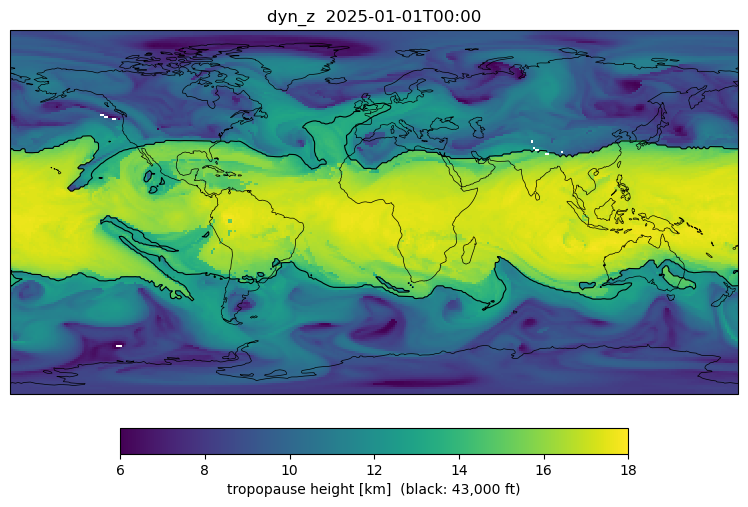

In [7]:
ZVAR = "dyn_z" if "dyn_z" in ZVARS else ZVARS[0]
T_INDEX = 0


def select(var):
    z = to_km(ds[var])
    if TIME is not None:
        z = z.mean(TIME, skipna=True) if T_INDEX is None else z.isel({TIME: T_INDEX})
    return z.transpose(LAT, LON)


def when():
    if TIME is None:
        return ""
    return "daily mean" if T_INDEX is None else str(ds[TIME].values[T_INDEX])[:16]


def draw(ax, da, vmin, vmax):
    data, x, y = da.values, da[LON].values, da[LAT].values
    kw = {}
    if HAVE_CARTOPY:
        data, x = add_cyclic_point(data, coord=x)
        kw["transform"] = ccrs.PlateCarree()
        ax.coastlines(lw=0.5)
    im = ax.pcolormesh(x, y, data, cmap="viridis", vmin=vmin, vmax=vmax, shading="auto", **kw)
    ax.contour(x, y, data, levels=[CEIL_KM], colors="k", linewidths=0.8, **kw)
    return im


kw = dict(subplot_kw=dict(projection=ccrs.PlateCarree())) if HAVE_CARTOPY else {}
fig, ax = plt.subplots(figsize=(11, 5.5), **kw)
im = draw(ax, select(ZVAR), 6, 18)
ax.set_title(f"{ZVAR}  {when()}")
fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.06, pad=0.08,
             label="tropopause height [km]  (black: 43,000 ft)")
plt.show()

## 7. All definitions, Southern Hemisphere 30–90°S

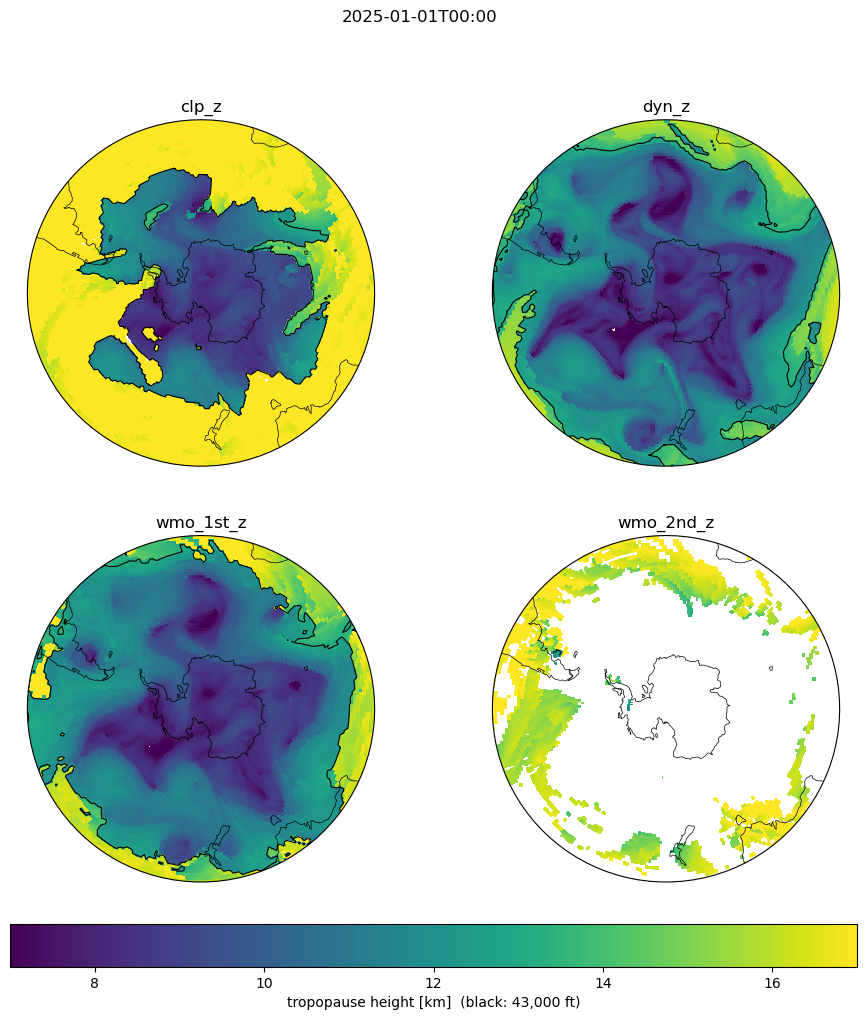

In [8]:
import matplotlib.path as mpath

n = len(ZVARS)
ncol = min(n, 2)
nrow = int(np.ceil(n / ncol))
kw = dict(subplot_kw=dict(projection=ccrs.SouthPolarStereo())) if HAVE_CARTOPY else {}
fig, axs = plt.subplots(nrow, ncol, figsize=(5.5 * ncol, 5.5 * nrow), squeeze=False, **kw)

theta = np.linspace(0, 2 * np.pi, 100)
circle = mpath.Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + 0.5)

for ax, v in zip(axs.flat, ZVARS):
    z = select(v)
    z = z.where(z[LAT] <= -30, drop=True)
    if HAVE_CARTOPY:
        ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
        ax.set_boundary(circle, transform=ax.transAxes)
    im = draw(ax, z, 7, 17)
    ax.set_title(v)
for ax in axs.flat[n:]:
    ax.set_visible(False)

fig.suptitle(when())
fig.colorbar(im, ax=axs, orientation="horizontal", fraction=0.05, pad=0.05,
             label="tropopause height [km]  (black: 43,000 ft)")
plt.show()

## 8. Zonal mean by definition

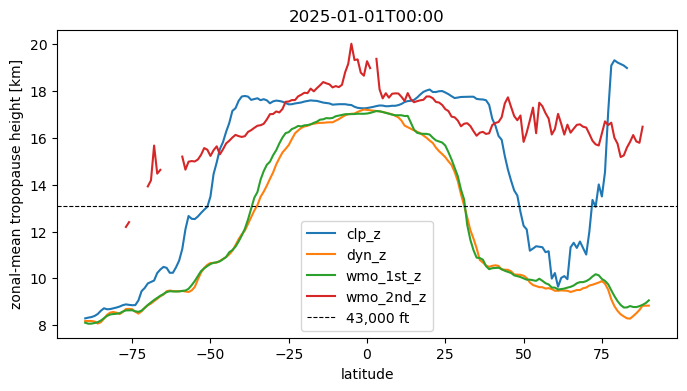

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
for v in ZVARS:
    z = select(v)
    ax.plot(z[LAT], z.mean(LON, skipna=True), label=v)
ax.axhline(CEIL_KM, color="k", ls="--", lw=0.8, label="43,000 ft")
ax.set_xlabel("latitude")
ax.set_ylabel("zonal-mean tropopause height [km]")
ax.set_title(when())
ax.legend()
plt.show()